In [1]:
import torch
from torch.utils.data import DataLoader, TensorDataset, Dataset, random_split
from torchvision import transforms
from PIL import Image
import os
import matplotlib.pyplot as plt
import numpy as np
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import torchvision
from typing import Tuple

# DATA ONBOARDING

In [2]:
class Data_Onboarding(Dataset):
    def __init__(self, d_type = 'Train', transform=None):
        if d_type == "Train":
            self.data = np.genfromtxt('data/train.csv', delimiter=',', dtype=None, encoding='utf-8')
            self.names = self.data[1:,0:1]
            self.data_f = self.data[1:,1:].astype(np.float32)
        else:
            self.data = np.genfromtxt('data/test.csv', delimiter=',', dtype=None, encoding='utf-8')
            self.names = self.data[1:,0:1]
            self.data_f = self.data[1:,1:].astype(np.float32)
        self.img_folder = "data/images"
        self.transform = transform
        
    def __len__(self):
        size = len(self.data)-1
        return size
    
    def __getitem__(self, idx):
        img_name = os.path.join(self.img_folder, self.names[idx].item())
        image = Image.open(img_name).convert('RGB')
        target = torch.tensor(self.data_f[idx], dtype=torch.float32)
        
        if self.transform:
            image = self.transform(image)
        
        return image, target

# Define transformations
transform = transforms.Compose([
    transforms.Resize((128, 128)),  # Resize images to 224x224
    transforms.ToTensor(),          # Convert images to tensors
])

# Load training and testing datasets
train_dataset = Data_Onboarding(transform=transform)
test_dataset = Data_Onboarding("Test",transform=transform)
total_size = len(train_dataset)
val_size = int(0.2 * total_size)  # 20% for validation
train_size = total_size - val_size

# Split the dataset
train_subset, val_subset = random_split(train_dataset, [train_size, val_size])

# Create new DataLoaders for train and validation sets
train_loader = DataLoader(train_subset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_subset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, shuffle=False)

# Now you have train_loader and val_loader
print(f"Training set size: {len(train_loader.dataset)}")
print(f"Validation set size: {len(val_loader.dataset)}")
print(f"Validation set size: {len(test_loader.dataset)}")

Training set size: 640
Validation set size: 160
Validation set size: 200


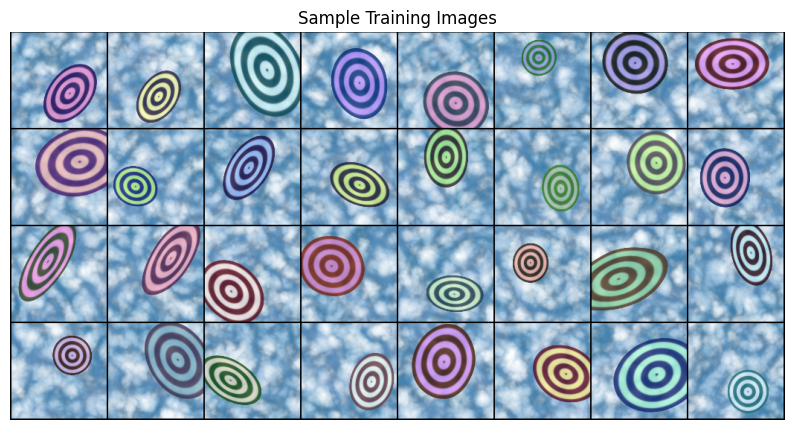

In [3]:
# Get a batch of training data
data_iter = iter(train_loader)
images, labels = next(data_iter)

# Make a grid from batch (use torchvision.utils.make_grid)
grid = torchvision.utils.make_grid(images, nrow=8, padding=2)

# Plot the grid
plt.figure(figsize=(10, 10))  
plt.imshow(grid.permute(1, 2, 0))  # Permute to (H, W, C) for plotting
plt.axis('off')  # Turn off the axis
plt.title("Sample Training Images")
plt.show()

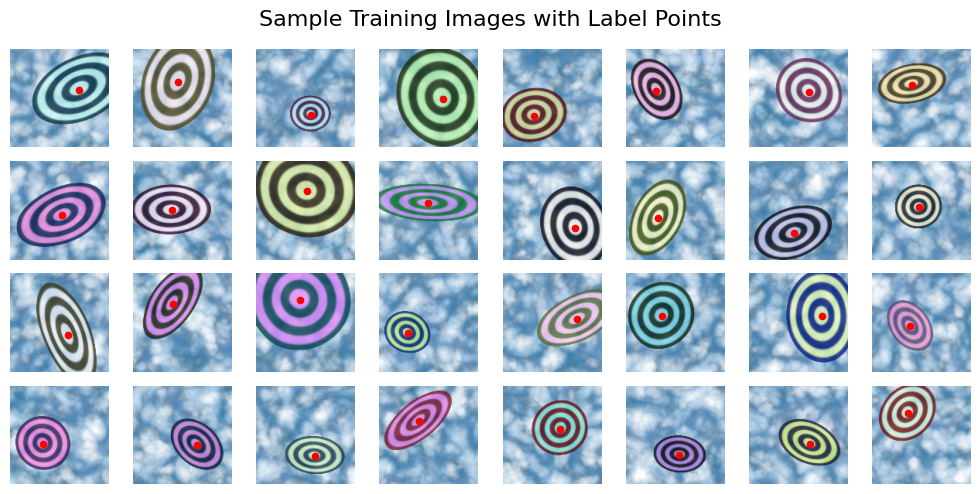

In [4]:
# Get a batch of training data
data_iter = iter(train_loader)
images, labels = next(data_iter)  # labels should contain x, y coordinates

# Make a grid from the batch
grid = torchvision.utils.make_grid(images, padding=2)
grid_images = grid.permute(1, 2, 0).numpy()  # Permute to (H, W, C)

# Normalize image values for display if needed
if grid_images.max() <= 1:
    grid_images = grid_images * 255  # Scale values to [0, 255]
grid_images = grid_images.astype('uint8')

# Plot each image in the batch with its label
plt.figure(figsize=(10, 5))

# For each image in the batch
for i in range(len(images)):
    # Get the individual image and label
    img = images[i].permute(1, 2, 0).numpy()
    if img.max() <= 1:
        img = img * 255  # Scale if needed
    img = img.astype('uint8')
    
    x, y = labels[i].numpy()  # Get x, y coordinates from labels
    
    # Subplot for each image
    plt.subplot(4, 8, i+1)
    plt.imshow(img)
    plt.scatter(x, y, c='red', s=20)  # Plot the label point in red
    plt.axis('off')  # Hide axes

plt.suptitle("Sample Training Images with Label Points", fontsize=16)
plt.tight_layout()
plt.show()


From the figure above, we are certain that our data has been treated for tensor trainning.
We used all channels of the data. No feature is exluded for now. However we will later check if we should use a single channel if the performance of the model is not that great.

# Model Implementation

In [3]:
class SimpleANN(nn.Module):
    def __init__(self):
        super(SimpleANN, self).__init__()
        self.fc1 = nn.Linear(3 * 128 * 128, 256)
        self.fc2 = nn.Linear( 256,128)
        self.fc3 = nn.Linear(128, 2)  # Predicting x and y positions

    def forward(self, x):
        x = x.view(x.size(0), -1)  # Flatten the image tensor
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x

S_model = SimpleANN()


In [10]:

class CNNRegression(nn.Module):
    """
    This will be the very basic CNN model we will use for the regression task.
    """
    def __init__(self, image_size: Tuple[int, int, int] = (3, 128, 128)):
        super(CNNRegression, self).__init__()
        self.image_size = image_size
        self.conv1 = nn.Conv2d(in_channels=self.image_size[0], out_channels=4, kernel_size=3, stride=1, padding=1)
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)
        self.conv2 = nn.Conv2d(in_channels=4, out_channels=16, kernel_size=3, stride=1, padding=1)
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)
        self.linear_line_size = int(16*(image_size[1]//4)*(image_size[2]//4))
        self.fc1 = nn.Linear(in_features=self.linear_line_size, out_features=128)
        self.fc2 = nn.Linear(in_features=128, out_features=2)

        
    def forward(self, x):
        """
        Passes the data through the network.
        There are commented out print statements that can be used to 
        check the size of the tensor at each layer. These are very useful when
        the image size changes and you want to check that the network layers are 
        still the correct shape.
        """
        x = self.conv1(x)
        # print('Size of tensor after each layer')
        # print(f'conv1 {x.size()}')
        x = nn.functional.relu(x)
        # print(f'relu1 {x.size()}')
        x = self.pool1(x)
        # print(f'pool1 {x.size()}')
        x = self.conv2(x)
        # print(f'conv2 {x.size()}')
        x = nn.functional.relu(x)
        # print(f'relu2 {x.size()}')
        x = self.pool2(x)
        # print(f'pool2 {x.size()}')
        x = x.view(-1, self.linear_line_size)
        # print(f'view1 {x.size()}')
        x = self.fc1(x)
        # print(f'fc1 {x.size()}')
        x = nn.functional.relu(x)
        # print(f'relu2 {x.size()}')
        x = self.fc2(x)
        # print(f'fc2 {x.size()}')
        return x
image_size: Tuple[int, int, int] = (3, 128, 128)
cnn_model = CNNRegression(image_size=image_size)

In [5]:
def train_model( model, train_loader=None, val_loader=None, num_epochs = 10, lr = 0.1, metric = nn.MSELoss()):
    # Define loss function and optimizer
    criterion =  metric # Mean Squared Error for regression tasks
    optimizer = optim.Adam(model.parameters(), lr=lr)

    train_err = []
    Mrrors_t = []
    Mrrors_v = []
    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0
        for inputs, coords in train_loader:
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, coords)
            # Backward pass and optimization
            train_err.append(loss)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
        if val_loader is not None:
            # Validation
            model.eval()
            running_val_loss = 0.0
            with torch.no_grad():
                for images, targets in val_loader:
                    outputs = model(images)
                    loss = criterion(outputs, targets)
                    #Mrrors_v.append(loss)
                    running_val_loss += loss.item()
                # Print the loss for every epoch
                epoch_loss = running_loss / len(train_loader)
        Mrrors_t.append(running_loss/len(train_loader))
        Mrrors_v.append(running_val_loss/len(val_loader))
        print(f"Epoch {epoch+1}/{num_epochs}, Train Loss: {running_loss/len(train_loader)}, Val Loss: {running_val_loss/len(val_loader)}")
    return (train_err,Mrrors_t,Mrrors_v)


### Trainig Models

In [ ]:
#Training for simple model
err_data = train_model(S_model,train_loader=train_loader,val_loader=val_loader,num_epochs=50,lr=0.001)

Epoch 1/50, Train Loss: 9462.709732055664, Val Loss: 462.578076171875
Epoch 2/50, Train Loss: 347.2763328552246, Val Loss: 288.4086608886719
Epoch 3/50, Train Loss: 285.45680236816406, Val Loss: 234.91668701171875
Epoch 4/50, Train Loss: 165.34274597167968, Val Loss: 156.32225799560547
Epoch 5/50, Train Loss: 115.848064994812, Val Loss: 107.29678497314453
Epoch 6/50, Train Loss: 89.69456539154052, Val Loss: 77.11249542236328
Epoch 7/50, Train Loss: 85.42903099060058, Val Loss: 83.5877082824707
Epoch 8/50, Train Loss: 71.32857646942139, Val Loss: 98.98565673828125
Epoch 9/50, Train Loss: 93.50093612670898, Val Loss: 108.56858825683594
Epoch 10/50, Train Loss: 69.87360553741455, Val Loss: 82.70038299560547
Epoch 11/50, Train Loss: 71.44620513916016, Val Loss: 70.52216415405273
Epoch 12/50, Train Loss: 85.60900077819824, Val Loss: 116.96538848876953
Epoch 13/50, Train Loss: 85.04223871231079, Val Loss: 75.01163177490234
Epoch 14/50, Train Loss: 55.93826141357422, Val Loss: 79.174604797363

In [11]:
#Training For Complex CNN Model
cnn_err_data = train_model(cnn_model,train_loader=train_loader,val_loader=val_loader,num_epochs=50,lr=0.01)

Epoch 1/50, Train Loss: 1237.3920318603516, Val Loss: 609.5649536132812
Epoch 2/50, Train Loss: 420.4036346435547, Val Loss: 360.7760803222656
Epoch 3/50, Train Loss: 342.2003921508789, Val Loss: 348.7506591796875
Epoch 4/50, Train Loss: 329.0687683105469, Val Loss: 332.2852722167969
Epoch 5/50, Train Loss: 322.3174591064453, Val Loss: 330.1381774902344
Epoch 6/50, Train Loss: 309.1596336364746, Val Loss: 295.9351440429688
Epoch 7/50, Train Loss: 252.73040008544922, Val Loss: 203.19091186523437
Epoch 8/50, Train Loss: 118.63378143310547, Val Loss: 70.61249465942383
Epoch 9/50, Train Loss: 55.129968070983885, Val Loss: 66.90077514648438
Epoch 10/50, Train Loss: 46.577866840362546, Val Loss: 52.85667953491211
Epoch 11/50, Train Loss: 34.53004655838013, Val Loss: 38.21636810302734
Epoch 12/50, Train Loss: 31.327095699310302, Val Loss: 35.81040573120117
Epoch 13/50, Train Loss: 27.637900733947752, Val Loss: 32.34999885559082
Epoch 14/50, Train Loss: 28.095777702331542, Val Loss: 36.1940467

In [13]:
def visualize_error(error, num_err=1,Train =True):
    """
    Visualize training and validation errors.

    Parameters:
    error (list or tuple): Contains error values. For num_err=1, it's a list of training errors.
                           For num_err=2, it's a tuple (train_errors, val_errors).
    num_err (int): Indicates the number of error sets to visualize. 
                   1 for training error only, 2 for both training and validation errors.
    """
    if num_err == 1 and Train:
        # Training error visualization
        dat, _,_ = error
        e_array = torch.stack(dat).detach().numpy()
        plt.plot(range(len(e_array)), e_array, label="Training Error", color='r')
        plt.xlabel("Epochs")
        plt.ylabel("Error")
        plt.legend(loc='upper right')  # Ensure legend is placed
        plt.title("General Training Error")
        plt.show()
    
    elif num_err == 2 and Train:
        # Training and validation error visualization
        _,train_errors, val_errors = error
        #train_array = torch.stack(train_errors).detach().numpy()
        #val_array = torch.stack(val_errors).detach().numpy()
        
        # Ensure both plot lines have labels for the legend
        plt.plot(range(len(train_errors)), train_errors, label="Train Error", color='r')
        plt.plot(range(len(val_errors)), val_errors, label="Validation Error", color='b')
        
        plt.xlabel("Epochs")
        plt.ylabel("Error")
        plt.legend(loc='upper right')  # Ensure legend is placed
        plt.title("Training and Validation Errors")
        plt.show()
    else:
        # Training error visualization
        dat = error
        #e_array = torch.stack(dat).detach().numpy()
        plt.plot(range(len(dat)), dat, label="Test Error", color='g')
        plt.xlabel("Epochs")
        plt.ylabel("Error")
        plt.legend(loc='upper right')  # Ensure legend is placed
        plt.title("Testing Error")
        plt.show()


####  Visualization for simple Model

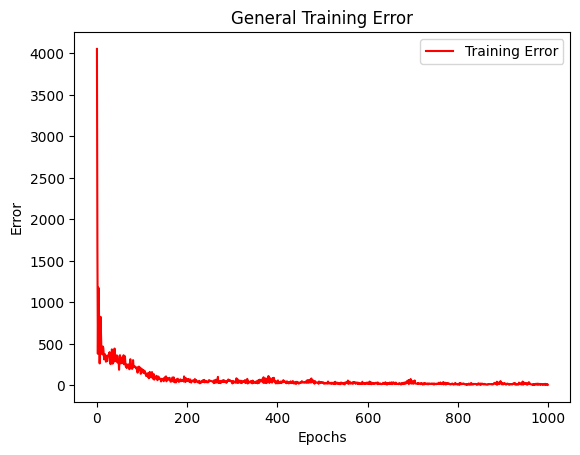

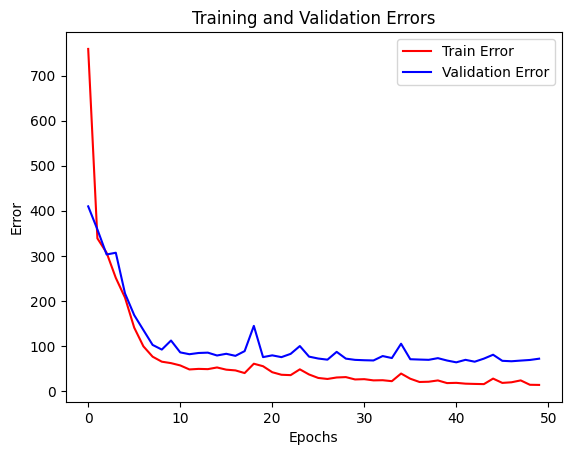

In [8]:
visualize_error(err_data,1)
visualize_error(err_data,2)

####  Visualization of Error for CNN Model

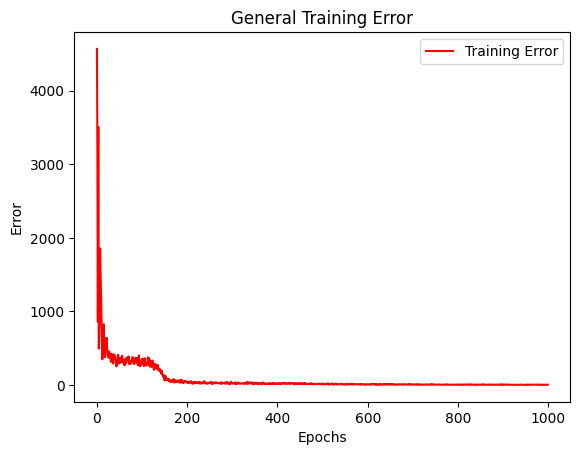

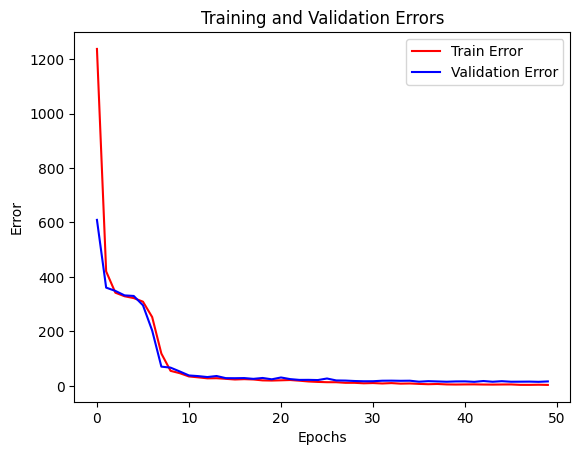

In [14]:
visualize_error(cnn_err_data,1)
visualize_error(cnn_err_data,2)

# Model Evaluation (Simple Model)

In [15]:
def evaluate( model, test_loader = None, metric = nn.MSELoss()):
    model.eval()
    Prediction = []
    Test_loss = []
    test_loss = 0.0
    criterion = metric
    with torch.no_grad():
        for images, targets in test_loader:
            outputs = model(images)
            Prediction.append(outputs.numpy())
            loss = criterion(outputs, targets)
            test_loss += loss.item()
            Test_loss.append(loss.item())
    print(f"Test Loss: {test_loss/len(test_loader)}")
    return (Prediction, Test_loss)


In [16]:
pred = evaluate(S_model,test_loader=test_loader)

Test Loss: 55.828597452268006


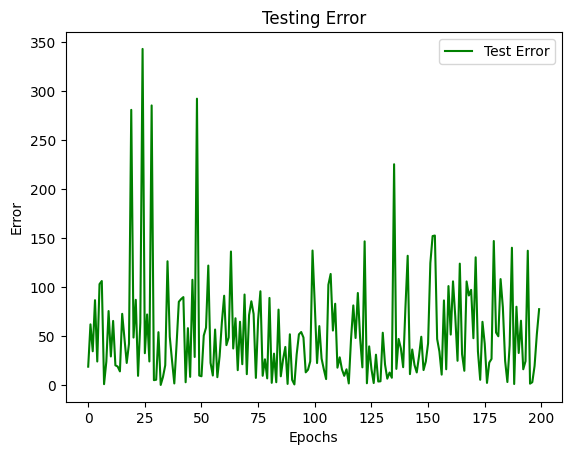

In [11]:
visualize_error(pred[1],1,False)

#### The test error is not comparable to neither train nor validation error

## Visualizing Prediction

In [20]:
def pred_visual(test_loader, pred):# Iterate through the entire test_loader
    data_iter = iter(test_loader)
    all_images, all_labels = [], []
    prediction = pred[0]
    # Collect all images and labels from test_loader
    for images, labels in data_iter:
        all_images.append(images)
        all_labels.append(labels)

    # Concatenate all images and labels into single tensors
    all_images = torch.cat(all_images)
    all_labels = torch.cat(all_labels)


    # Plot each image with true and predicted points
    num_images = len(all_images)
    plt.figure(figsize=(12, 6))

    for i in range(5):
        img = all_images[i].permute(1, 2, 0).numpy()
        
        if img.max() <= 1:
            img = (img * 255).astype('uint8')
        
        x, y = all_labels[i].numpy()  # Ground truth x, y
        x_hat, y_hat = prediction[i][0]  # Predicted x, y

        # Subplot for each image
        plt.subplot((5 // 5) + 1, 5, i + 1)
        plt.imshow(img)
        plt.scatter(x, y, c='blue', s=20, label="True")  # True label point
        plt.scatter(x_hat, y_hat, c='red', s=20, label="Pred")  # Predicted point
        plt.axis('off')
        
        if i == 0:  # Show legend only on the first subplot
            plt.legend(loc="upper left", fontsize=8)

    plt.suptitle("Test Images with True and Predicted Points", fontsize=16)
    plt.tight_layout()
    plt.show()
    return all_labels


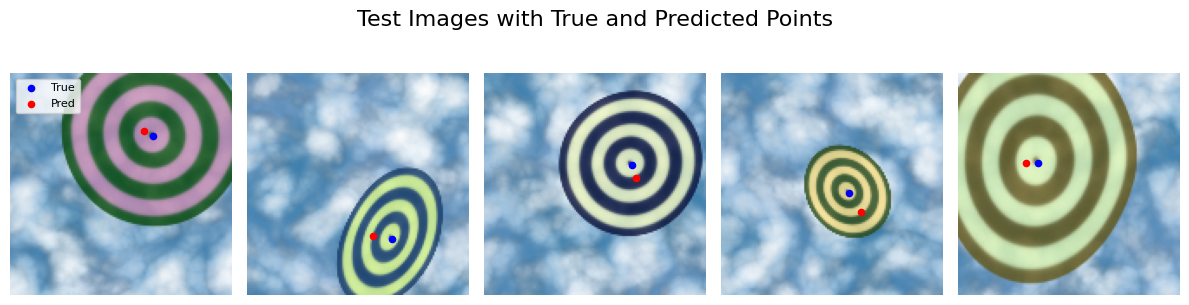

In [15]:
all_lab = pred_visual(test_loader, pred)

### How far off is the predicted value?

Using the Euclidean distance, On average the distance betwwen the true label and the predicted label is 359.65137 cm

# Model Evaluation (CNN Model)

In [17]:
pred = evaluate(cnn_model,test_loader=test_loader)

Test Loss: 15.822674375008791


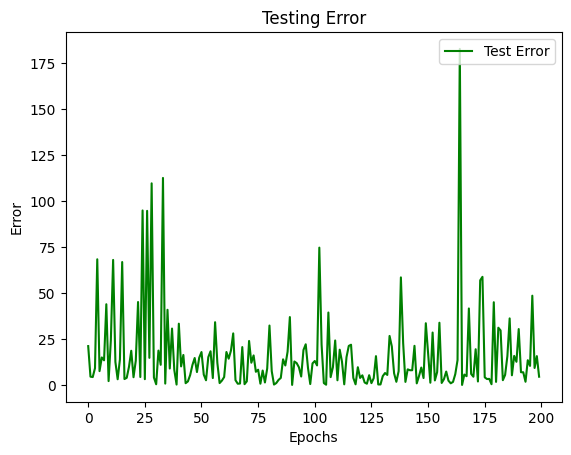

In [21]:
visualize_error(pred[1],1,False)

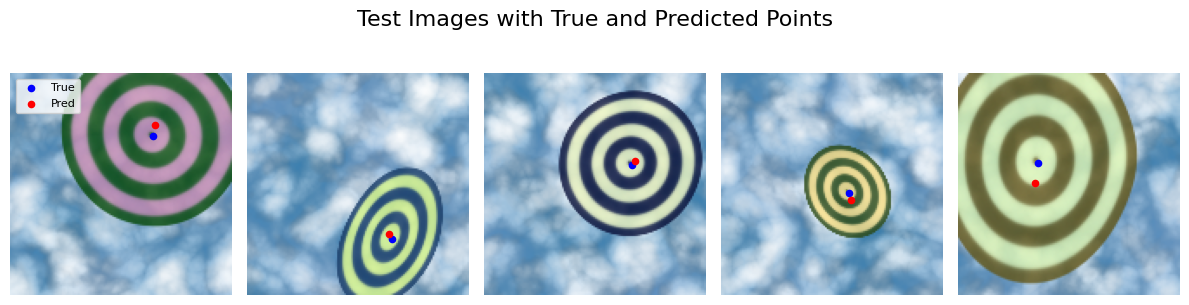

In [22]:
all_lab = pred_visual(test_loader, pred)

### How far off is the predicted value?

In [26]:
#Using the Euclidean Distance
prediction = pred[0]
rmse = np.sqrt(np.mean(np.sum((all_lab.numpy() - prediction) ** 2, axis=1)))
print("Root Mean Squared Error:", rmse)


Root Mean Squared Error: 367.07425


With the CNN model,  the average the distance betwwen the true label and the predicted label reduces to  367.07425 cm